In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import accuracy_score

In [2]:
import datetime
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud

import csv

In [3]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Loading Dataset

In [4]:
au_df = pd.read_csv('/content/chatgpt_review_au.csv')
ca_df = pd.read_csv('/content/chatgpt_review_ca.csv')
gb_df = pd.read_csv('/content/chatgpt_review_gb.csv')
us_df = pd.read_csv('/content/chatgpt_review_us.csv')

# standarizing
ca_df = ca_df.rename(columns={'Review': 'content'})

chatjipiti = pd.concat([au_df, ca_df, gb_df, us_df], ignore_index=True)

In [5]:
chatjipiti.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1831500 entries, 0 to 1831499
Data columns (total 2 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   content  object
 1   Review   object
dtypes: object(2)
memory usage: 27.9+ MB


In [6]:
chatjipiti.head(-10)

,content,Review
0,Exceptional. It even asks back-up questions I ...,NaN
1,I made the full payment two weeks ago to subsc...,NaN
2,Voice dictation consistently failing when it i...,NaN
3,I got ChatGPT to write this review for me! I w...,NaN
4,Its starting to become predatory after a free ...,NaN
...,...,...
1831485,NaN,excellent
1831486,NaN,nice
1831487,NaN,best
1831488,NaN,good


In [7]:
chatjipiti = chatjipiti.drop(columns='Review')
chatjipiti = chatjipiti.dropna()
chatjipiti = chatjipiti.drop_duplicates()
col, row = chatjipiti.shape
print(f"Number of columns: {col}")

Number of columns: 368021


In [8]:
# importing to csv in case my session in colab got fucking terminate again
pd.DataFrame(chatjipiti).to_csv('chatjipiti.csv', index=False)

## Preprocessing Text

In [9]:
import re

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip(' ')
    return text


def casefoldText(text):
    return text.lower()

def tokenizingText(text):
    return word_tokenize(text)

def filterText(text):
    stopwordList = set(stopwords.words('english'))
    filtered = []
    for txt in text:
        if txt not in stopwordList:
            filtered.append(txt)

    return filtered


from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

def stemmingText(text):
   word = text.split()
   lemmatizer = WordNetLemmatizer()
   text = [lemmatizer.lemmatize(word, pos=wordnet.VERB) for word in text]

   return text

def toSentence(listWord):
    sentence = ' '.join(word for word in listWord)
    return sentence



[nltk_data] Downloading package wordnet to /root/nltk_data...


In [10]:
chatjipiti['text_clean'] = chatjipiti['content'].apply(cleaningText)
chatjipiti['text_casefoldingText'] = chatjipiti['text_clean'].apply(casefoldText)
chatjipiti['text_tokenizingText'] = chatjipiti['text_casefoldingText'].apply(tokenizingText)
chatjipiti['text_stopword'] = chatjipiti['text_tokenizingText'].apply(filterText)
chatjipiti['final'] = chatjipiti['text_stopword'].apply(toSentence)

In [11]:
chatjipiti.head(-5)

,content,text_clean,text_casefoldingText,text_tokenizingText,text_stopword,final
0,Exceptional. It even asks back-up questions I ...,Exceptional It even asks backup questions I wo...,exceptional it even asks backup questions i wo...,"[exceptional, it, even, asks, backup, question...","[exceptional, even, asks, backup, questions, w...",exceptional even asks backup questions wouldnt...
1,I made the full payment two weeks ago to subsc...,I made the full payment two weeks ago to subsc...,i made the full payment two weeks ago to subsc...,"[i, made, the, full, payment, two, weeks, ago,...","[made, full, payment, two, weeks, ago, subscri...",made full payment two weeks ago subscribe plus...
2,Voice dictation consistently failing when it i...,Voice dictation consistently failing when it i...,voice dictation consistently failing when it i...,"[voice, dictation, consistently, failing, when...","[voice, dictation, consistently, failing, minu...",voice dictation consistently failing minutes l...
3,I got ChatGPT to write this review for me! I w...,I got ChatGPT to write this review for me I wa...,i got chatgpt to write this review for me i wa...,"[i, got, chatgpt, to, write, this, review, for...","[got, chatgpt, write, review, pro, user, subsc...",got chatgpt write review pro user subscription...
4,Its starting to become predatory after a free ...,Its starting to become predatory after a free ...,its starting to become predatory after a free ...,"[its, starting, to, become, predatory, after, ...","[starting, become, predatory, free, pro, trial...",starting become predatory free pro trial cuts ...
...,...,...,...,...,...,...
1151988,it's make hard to easy,its make hard to easy,its make hard to easy,"[its, make, hard, to, easy]","[make, hard, easy]",make hard easy
1151989,Simply the best !,Simply the best,simply the best,"[simply, the, best]","[simply, best]",simply best
1151990,Best Artificial intelligence,Best Artificial intelligence,best artificial intelligence,"[best, artificial, intelligence]","[best, artificial, intelligence]",best artificial intelligence
1151991,very gud for study,very gud for study,very gud for study,"[very, gud, for, study]","[gud, study]",gud study


In [12]:
chatjipiti.info()

<class 'pandas.core.frame.DataFrame'>
Index: 368021 entries, 0 to 1151999
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   content               368021 non-null  object
 1   text_clean            368021 non-null  object
 2   text_casefoldingText  368021 non-null  object
 3   text_tokenizingText   368021 non-null  object
 4   text_stopword         368021 non-null  object
 5   final                 368021 non-null  object
dtypes: object(6)
memory usage: 19.7+ MB


## Labeling

In [13]:
import pandas as pd
import requests
from io import StringIO

# lexicon that used: AFINN-111
url = "https://raw.githubusercontent.com/fnielsen/afinn/master/afinn/data/AFINN-111.txt"

response = requests.get(url)
data = response.text

df = pd.read_csv(StringIO(data), sep='\t', header=None, names=['word', 'score'])

# Save to CSV
df.to_csv('afinn_111.csv', index=False)

In [14]:
lexicon = dict()
with open('/content/afinn_111.csv', 'r') as file:
    reader = csv.reader(file, delimiter=',')
    next(reader, None) # Skip the header row
    for row in reader:
        if len(row) >= 2:
            lexicon[row[0]] = int(row[1])
        else:
            print(f"skipping {row}, error")

In [15]:
def sentiment_analysis(text):
    score = 0

    for word in text:
        score = score + lexicon.get(word, 0)

    polarity=''

    if (score > 1):
        polarity = 'positive'
    elif (score < -1):
        polarity = 'negative'

    else:
        polarity = 'neutral'

    return score, polarity

In [16]:
def sentiment_analysis_num(text):
    if text == 'positive':
        return 1
    elif text == 'negative':
        return -1
    else:
        return 0

In [17]:
results = chatjipiti['text_stopword'].apply(sentiment_analysis)
results = list(zip(*results))
chatjipiti['polarity_score'] = results[0]
chatjipiti['polarity'] = results[1]
chatjipiti.head(-10)

,content,text_clean,text_casefoldingText,text_tokenizingText,text_stopword,final,polarity_score,polarity
0,Exceptional. It even asks back-up questions I ...,Exceptional It even asks backup questions I wo...,exceptional it even asks backup questions i wo...,"[exceptional, it, even, asks, backup, question...","[exceptional, even, asks, backup, questions, w...",exceptional even asks backup questions wouldnt...,12,positive
1,I made the full payment two weeks ago to subsc...,I made the full payment two weeks ago to subsc...,i made the full payment two weeks ago to subsc...,"[i, made, the, full, payment, two, weeks, ago,...","[made, full, payment, two, weeks, ago, subscri...",made full payment two weeks ago subscribe plus...,-4,negative
2,Voice dictation consistently failing when it i...,Voice dictation consistently failing when it i...,voice dictation consistently failing when it i...,"[voice, dictation, consistently, failing, when...","[voice, dictation, consistently, failing, minu...",voice dictation consistently failing minutes l...,-1,neutral
3,I got ChatGPT to write this review for me! I w...,I got ChatGPT to write this review for me I wa...,i got chatgpt to write this review for me i wa...,"[i, got, chatgpt, to, write, this, review, for...","[got, chatgpt, write, review, pro, user, subsc...",got chatgpt write review pro user subscription...,-2,negative
4,Its starting to become predatory after a free ...,Its starting to become predatory after a free ...,its starting to become predatory after a free ...,"[its, starting, to, become, predatory, after, ...","[starting, become, predatory, free, pro, trial...",starting become predatory free pro trial cuts ...,6,positive
...,...,...,...,...,...,...,...,...
1151980,This app is very excellent,This app is very excellent,this app is very excellent,"[this, app, is, very, excellent]","[app, excellent]",app excellent,3,positive
1151981,very good and helpful 👍🏻,very good and helpful,very good and helpful,"[very, good, and, helpful]","[good, helpful]",good helpful,5,positive
1151983,Ilove Chat GPT❤️❤️❤️❤️❤️ i love so much,Ilove Chat GPT i love so much,ilove chat gpt i love so much,"[ilove, chat, gpt, i, love, so, much]","[ilove, chat, gpt, love, much]",ilove chat gpt love much,3,positive
1151984,not working on my device but why,not working on my device but why,not working on my device but why,"[not, working, on, my, device, but, why]","[working, device]",working device,0,neutral


polarity
positive    270898
neutral      73879
negative     23244
Name: count, dtype: int64


<Axes: xlabel='polarity', ylabel='count'>

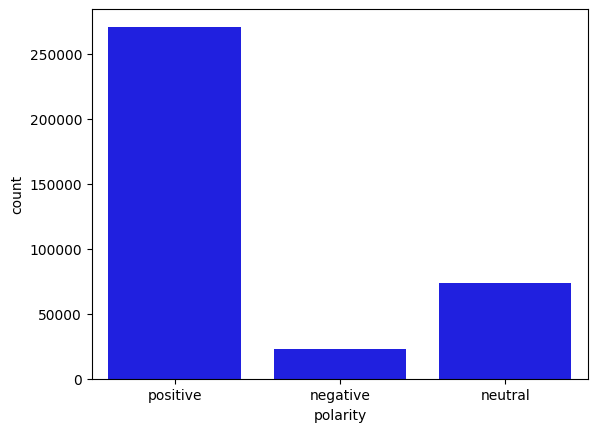

In [18]:
print(chatjipiti['polarity'].value_counts())
sns.countplot(x='polarity', data=chatjipiti, color='blue')

## Data Splitting

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = chatjipiti['final']
y = chatjipiti['polarity']

tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
features_df
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

## Data Oversampling
Since our dataset has a significant imbalance (more positive than negative reviews), we will use SMOTE to oversample the minority class in the training set

In [20]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit SMOTE to the training data
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {Counter(y_train)}")
print(f"Resampled training shape: {Counter(y_train)}")

Original training shape: Counter({'neutral': 216746, 'positive': 216746, 'negative': 216746})
Resampled training shape: Counter({'neutral': 216746, 'positive': 216746, 'negative': 216746})


## Modeling

### Control method: Naive Bayes Method

In [21]:
from sklearn.naive_bayes import BernoulliNB

naive_bayes = BernoulliNB()
naive_bayes.fit(X_train.toarray(), y_train)

y_pred_naive = naive_bayes.predict(X_test.toarray())

print('Balanced Naive Bayes - accuracy_test:', accuracy_score(y_test, y_pred_naive))

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_naive))

Balanced Naive Bayes - accuracy_test: 0.7943753821071938
              precision    recall  f1-score   support

    negative       0.29      0.56      0.38      4628
     neutral       0.60      0.72      0.65     14825
    positive       0.96      0.83      0.89     54152

    accuracy                           0.79     73605
   macro avg       0.62      0.70      0.64     73605
weighted avg       0.85      0.79      0.81     73605



Takes on controll method: while the data already oversampled that lead to 89% F1 sscoer, the score precision for negative class is still bad

## Converting Dataset INto DL fit Format

In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

max_features = 5000
tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(chatjipiti['final'].values)
X_seq = tokenizer.texts_to_sequences(chatjipiti['final'].values)
max_len = max(len(x) for x in X_seq)
X_pad = pad_sequences(X_seq, maxlen=max_len)

le = LabelEncoder()
y_enc = le.fit_transform(chatjipiti['polarity'])
y_onehot = tf.keras.utils.to_categorical(y_enc)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_pad, y_onehot, test_size=0.2, random_state=42)

### Scheme 1: LSTM

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
import tensorflow as tf

device = '/device:GPU:0' if tf.config.list_physical_devices('GPU') else '/device:CPU:0'
print(f"using {device}")

with tf.device(device):
    lstm_model = Sequential([
        Embedding(max_features, 32),
        SpatialDropout1D(0.2),
        LSTM(64, dropout=0.2, recurrent_dropout=0),
        Dense(3, activation='softmax')
    ])
    lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    lstm_res = lstm_model.fit(X_train_dl, y_train_dl, epochs=3, batch_size=64, validation_split=0.1, verbose=1)

using /device:CPU:0
Epoch 1/3
4141/4141 ━━━━━━━━━━━━━━━━━━━━ 243s 58ms/step - accuracy: 0.9445 - loss: 0.1515 - val_accuracy: 0.9732 - val_loss: 0.0818
Epoch 2/3
4141/4141 ━━━━━━━━━━━━━━━━━━━━ 236s 57ms/step - accuracy: 0.9773 - loss: 0.0712 - val_accuracy: 0.9778 - val_loss: 0.0708
Epoch 3/3
4141/4141 ━━━━━━━━━━━━━━━━━━━━ 243s 59ms/step - accuracy: 0.9838 - loss: 0.0565 - val_accuracy: 0.9846 - val_loss: 0.0579


In [24]:
y_pred_lstm_probs = lstm_model.predict(X_test_dl)
y_pred_lstm_indices = np.argmax(y_pred_lstm_probs, axis=1)

y_test_indices = np.argmax(y_test_dl, axis=1)

print("LSTM Classification report")
print(classification_report(y_test_indices, y_pred_lstm_indices, target_names=le.classes_))

2301/2301 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step
LSTM Classification report
              precision    recall  f1-score   support

    negative       0.98      0.92      0.95      4628
     neutral       0.96      0.97      0.97     14825
    positive       0.99      1.00      0.99     54152

    accuracy                           0.99     73605
   macro avg       0.98      0.96      0.97     73605
weighted avg       0.99      0.99      0.99     73605



### Scheme 2: Conv1D

In [25]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

device = '/device:GPU:0' if tf.config.list_physical_devices('GPU') else '/device:CPU:0'
print(f"using {device}")

with tf.device(device):
    model_cnn = Sequential([
        Embedding(max_features, 32),
        SpatialDropout1D(0.2),
        Conv1D(64, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(3, activation='softmax')
    ])
    model_cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    oned_cnn_res = model_cnn.fit(X_train_dl, y_train_dl, epochs=3, batch_size=64, validation_split=0.1, verbose=1)

using /device:CPU:0
Epoch 1/3
4141/4141 ━━━━━━━━━━━━━━━━━━━━ 70s 17ms/step - accuracy: 0.9466 - loss: 0.1514 - val_accuracy: 0.9694 - val_loss: 0.0916
Epoch 2/3
4141/4141 ━━━━━━━━━━━━━━━━━━━━ 66s 16ms/step - accuracy: 0.9729 - loss: 0.0827 - val_accuracy: 0.9717 - val_loss: 0.0875
Epoch 3/3
4141/4141 ━━━━━━━━━━━━━━━━━━━━ 67s 16ms/step - accuracy: 0.9777 - loss: 0.0695 - val_accuracy: 0.9738 - val_loss: 0.0829


In [26]:
y_pred_cnn_probs = model_cnn.predict(X_test_dl)
y_pred_cnn_indices = np.argmax(y_pred_cnn_probs, axis=1)

print("Conv1D Classification Report:")
print(classification_report(y_test_indices, y_pred_cnn_indices, target_names=le.classes_))

2301/2301 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
Conv1D Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.90      0.91      4628
     neutral       0.94      0.94      0.94     14825
    positive       0.99      0.99      0.99     54152

    accuracy                           0.97     73605
   macro avg       0.95      0.94      0.95     73605
weighted avg       0.97      0.97      0.97     73605



### Scheme 3: GRU (Gated Recurrent Unit)

In [27]:
from tensorflow.keras.layers import GRU

device = '/device:GPU:0' if tf.config.list_physical_devices('GPU') else '/device:CPU:0'
print(f"Training GRU on {device}")

with tf.device(device):
    model_gru = Sequential([
        Embedding(max_features, 32),
        SpatialDropout1D(0.2),
        GRU(64, dropout=0.2, recurrent_dropout=0),
        Dense(3, activation='softmax')
    ])
    model_gru.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    gru_res = model_gru.fit(X_train_dl, y_train_dl, epochs=3, batch_size=64, validation_split=0.1, verbose=1)

Training GRU on /device:CPU:0
Epoch 1/3
4141/4141 ━━━━━━━━━━━━━━━━━━━━ 291s 70ms/step - accuracy: 0.9471 - loss: 0.1472 - val_accuracy: 0.9742 - val_loss: 0.0804
Epoch 2/3
4141/4141 ━━━━━━━━━━━━━━━━━━━━ 292s 71ms/step - accuracy: 0.9752 - loss: 0.0759 - val_accuracy: 0.9773 - val_loss: 0.0723
Epoch 3/3
4141/4141 ━━━━━━━━━━━━━━━━━━━━ 326s 71ms/step - accuracy: 0.9817 - loss: 0.0609 - val_accuracy: 0.9820 - val_loss: 0.0628


In [28]:
y_pred_gru_probs = model_gru.predict(X_test_dl)
y_pred_gru_indices = np.argmax(y_pred_gru_probs, axis=1)

print("GRU Classification Report:")
print(classification_report(y_test_indices, y_pred_gru_indices, target_names=le.classes_))

2301/2301 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step
GRU Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.92      0.94      4628
     neutral       0.95      0.97      0.96     14825
    positive       0.99      0.99      0.99     54152

    accuracy                           0.98     73605
   macro avg       0.97      0.96      0.97     73605
weighted avg       0.98      0.98      0.98     73605



## Inference Test

In [29]:
# Take a sample from the dataframe
sample_size = 100
inference_sample = chatjipiti.sample(sample_size, random_state=42)

# Get the text_clean and the actual labels
raw_texts = inference_sample['text_clean'].values
actual_polarities = inference_sample['polarity'].values

# Prepare the text for the deep learning models using the existing tokenizer
sequences = tokenizer.texts_to_sequences(raw_texts)
padded_sequences = pad_sequences(sequences, maxlen=max_len)

# Predict using the models
pred_lstm = np.argmax(lstm_model.predict(padded_sequences), axis=1)
pred_cnn = np.argmax(model_cnn.predict(padded_sequences), axis=1)
pred_gru = np.argmax(model_gru.predict(padded_sequences), axis=1)

# Map numerical predictions back to labels
predicted_labels_lstm = le.inverse_transform(pred_lstm)
predicted_labels_cnn = le.inverse_transform(pred_cnn)
predicted_labels_gru = le.inverse_transform(pred_gru)

# Print Classification Reports
print("LSTM Classification Report ")
print(classification_report(actual_polarities, predicted_labels_lstm))

print("\nCNN Classification Report")
print(classification_report(actual_polarities, predicted_labels_cnn))

print("\nGRU Classification Report")
print(classification_report(actual_polarities, predicted_labels_gru))

# results_df = pd.DataFrame({
#     'Clean Text': raw_texts,
#     'Actual': actual_polarities,
#     'LSTM Pred': predicted_labels_lstm,
#     'CNN Pred': predicted_labels_cnn,
#     'GRU Pred': predicted_labels_gru
# })

# results_df

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
LSTM Classification Report 
              precision    recall  f1-score   support

    negative       1.00      0.67      0.80         3
     neutral       0.90      1.00      0.95        18
    positive       1.00      0.99      0.99        79

    accuracy                           0.98       100
   macro avg       0.97      0.88      0.91       100
weighted avg       0.98      0.98      0.98       100


CNN Classification Report
              precision    recall  f1-score   support

    negative       0.50      0.33      0.40         3
     neutral       0.81      0.94      0.87        18
    positive       1.00      0.97      0.99        79

    accuracy                           0.95       100
   macro avg       0.77      0.75      0.75       100
weighted avg       0.95      0.95      0.95       100


GRU Classification Report
              precision    recall  f1-scor